## Read data

### Read libraries

In [ ]:
from src.data_preprocessing import drop_empty_cols_and_rows, drop_columns
import os
import json
from sklearn.model_selection import train_test_split
import joblib
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier  # make sure xgboost is installed
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix
)
import openpyxl
from sklearn.metrics import roc_curve


### Read data

In [ ]:
# Full data set or subset of columns
big_KOI_data = False
if big_KOI_data:
    data_name = "Kepler full"
    path = "datasets/KOI_2025.10.03_07.23.34.csv"
    skiprow_nr = 144
else: 
    data_name = "Kepler subset"
    path = 'datasets/KOI_cumulative.csv'
    skiprow_nr = 53

df_orig = pd.read_csv(path, skiprows=skiprow_nr)
df_orig.head()

,loc_rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


## Clean data

In [29]:
df = drop_empty_cols_and_rows(df_orig)

Original shape: (9564, 50)
After dropping all-empty columns: (9564, 48)
After dropping all-empty rows: (9564, 48)


#### Remove specified columns

In [31]:
df = drop_columns(df, big_KOI_data)

#### Filtered on Confirmed and X

In [ ]:
label_A = "CONFIRMED"
label_B = "CANDIDATE" # FALSE POSITIVE was also used during development
# Step 1: Filter out FP
df_rem_filtered = df[df['koi_disposition'].isin([label_A, label_B])].copy()

if label_B=="FALSE POSITIVE":
    # remove all columns with false positive flags (flg somewhere in column name)
    fp_cols = [col for col in df_rem_filtered.columns if "fpflag" in col.lower()]
    if fp_cols:
        df_rem_filtered = df_rem_filtered.drop(columns=fp_cols)
        print(f"Dropped fpflag columns: {fp_cols}")

print("Remaining dispositions:\n", df_rem_filtered['koi_disposition'].value_counts())

Remaining dispositions:
 koi_disposition
CONFIRMED    2746
CANDIDATE    1979
Name: count, dtype: int64


In [33]:
df_rem_filtered.head()

,koi_disposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,CONFIRMED,0,0,0,0,9.488036,0.000028,-0.000028,170.538750,0.002160,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,CONFIRMED,0,0,0,0,54.418383,0.000248,-0.000248,162.513840,0.003520,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,CANDIDATE,0,0,0,0,19.899140,0.000015,-0.000015,175.850252,0.000581,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
4,CONFIRMED,0,0,0,0,2.525592,0.000004,-0.000004,171.595550,0.001130,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509
5,CONFIRMED,0,0,0,0,11.094321,0.000020,-0.000020,171.201160,0.001410,...,-232.0,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714


### Check correlation between target variable

In [ ]:
df_binary = df_rem_filtered.copy()
le = LabelEncoder()
df_binary['label'] = le.fit_transform(df_binary['koi_disposition'])


In [35]:
# Select only numeric features
numeric_cols = df_binary.select_dtypes(include=['int64','float64']).columns

# Correlation matrix with the label
correlations = df_binary[numeric_cols].corrwith(df_binary['label']).sort_values(key=abs, ascending=False)
print("Top correlations with koi_disposition:\n", correlations)


Top correlations with koi_disposition:
 label                1.000000
koi_duration_err2    0.345486
koi_duration_err1   -0.345486
koi_period_err2      0.274899
koi_period_err1     -0.274899
koi_time0bk_err2     0.269956
koi_time0bk_err1    -0.269956
koi_steff_err2       0.269664
koi_slogg_err2       0.269407
koi_steff_err1      -0.256912
koi_srad_err1       -0.200281
koi_time0bk         -0.181517
koi_slogg            0.161639
koi_depth_err2       0.150636
koi_depth_err1      -0.150636
koi_srad_err2        0.136093
koi_steff           -0.135714
koi_duration        -0.132691
koi_slogg_err1      -0.128582
koi_model_snr        0.111828
koi_impact_err1     -0.087014
koi_srad            -0.079838
ra                  -0.072120
koi_tce_plnt_num     0.070182
koi_insol           -0.056798
koi_insol_err2       0.055581
koi_insol_err1      -0.052649
koi_impact          -0.041778
koi_period          -0.036410
koi_fpflag_ss        0.034716
koi_prad_err1       -0.034411
koi_prad            -0.027762


c:\Projects\NASA Space App Challenge - XOXOplanet\xoxoplanet-nasa2025\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Projects\NASA Space App Challenge - XOXOplanet\xoxoplanet-nasa2025\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Exploratory data analysis

In [ ]:
def plot_EAD(df):
    # --- 1. Basic info ---
    print("Shape of dataset:", df.shape)
    print("Columns available:", df.columns.tolist()[:20], "...")  # show first 20 cols
    print("\nDisposition value counts:\n", df['koi_disposition'].value_counts())

    # --- 2. Label balance (planet vs false positive vs candidate) ---
    plt.figure(figsize=(6,4))
    sns.countplot(x="koi_disposition", data=df, order=df['koi_disposition'].value_counts().index)
    plt.title("Exoplanet Candidate Dispositions")
    plt.ylabel("Count")
    plt.xlabel("Disposition")
    plt.xticks(rotation=20)
    plt.show()

    # --- 3. Key distributions (period, depth, signal-to-noise ratio) ---
    # koi_period = orbital period (days)
    # koi_depth = transit depth (ppm)
    # koi_model_snr = model signal-to-noise ratio
    features = ['koi_period', 'koi_depth', 'koi_model_snr']
    titles = ['Orbital Period (days)', 'Transit Depth (ppm)', 'Signal-to-Noise Ratio']

    plt.figure(figsize=(15,4))
    for i, (feat, title) in enumerate(zip(features, titles)):
        plt.subplot(1,3,i+1)
        sns.histplot(df[feat].dropna(), bins=50, kde=False)
        plt.xlabel(title)
        plt.ylabel("Count")
        plt.yscale("log")  # log scale helps with skewed distributions
    plt.suptitle("Distribution of Key Features")
    plt.tight_layout()
    plt.show()

    # --- 4. Compare distributions by disposition ---
    plt.figure(figsize=(12,4))
    sns.boxplot(x="koi_disposition", y="koi_model_snr", data=df)
    plt.title("Signal-to-Noise by Disposition")
    plt.yscale("log")
    plt.show()

    plt.figure(figsize=(12,4))
    sns.boxplot(x="koi_disposition", y="koi_depth", data=df)
    plt.title("Transit Depth by Disposition")
    plt.yscale("log")
    plt.show()

    if label_B != "FALSE POSITIVE":
        # --- 5. Noise patterns exploration ---
        # Flag columns indicate potential false positives
        fp_flags = ['koi_fpflag_nt','koi_fpflag_ss','koi_fpflag_co','koi_fpflag_ec']

        for col in fp_flags:
            if col in df.columns:
                print(f"\n{col} value counts:\n", df[col].value_counts())

        plt.figure(figsize=(8,5))
        sns.heatmap(df[fp_flags].corr(), annot=True, cmap="coolwarm")
        plt.title("Correlation of False Positive Flags")
        plt.show()


Shape of dataset: (4725, 42)
Columns available: ['koi_disposition', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec', 'koi_period', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk', 'koi_time0bk_err1', 'koi_time0bk_err2', 'koi_impact', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration', 'koi_duration_err1', 'koi_duration_err2', 'koi_depth', 'koi_depth_err1', 'koi_depth_err2'] ...

Disposition value counts:
 koi_disposition
CONFIRMED    2746
CANDIDATE    1979
Name: count, dtype: int64


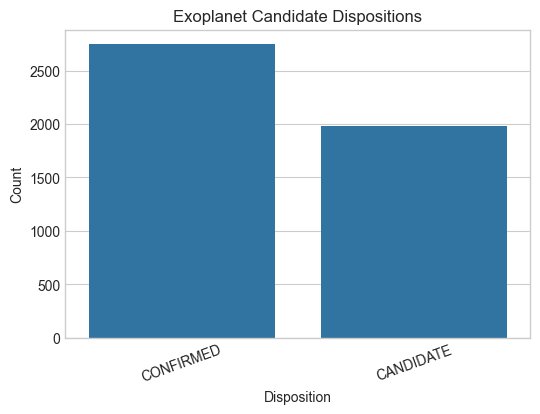

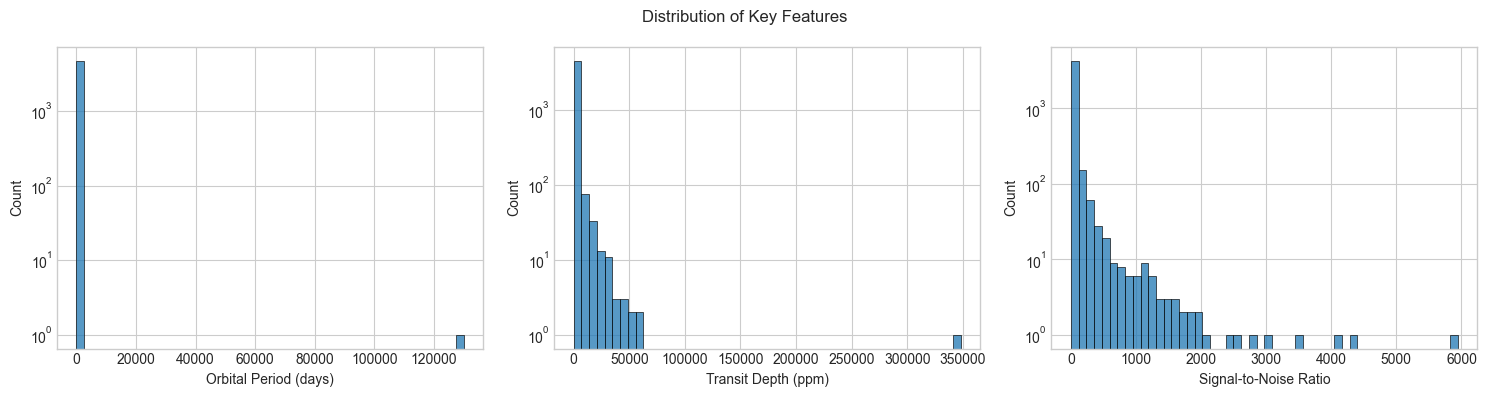

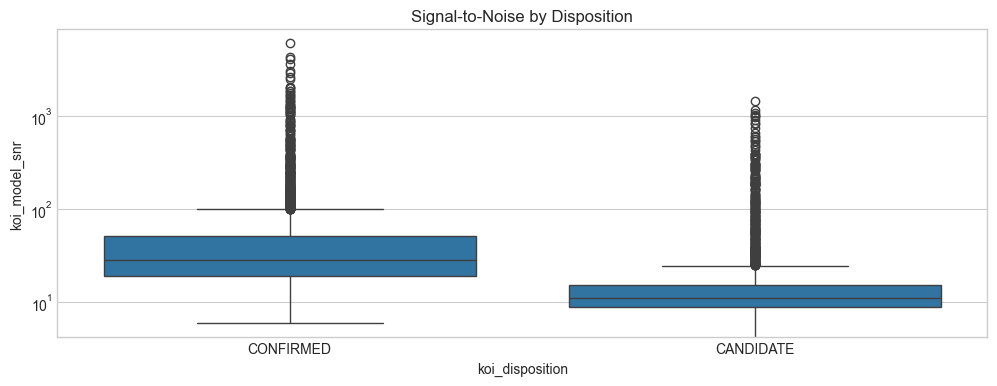

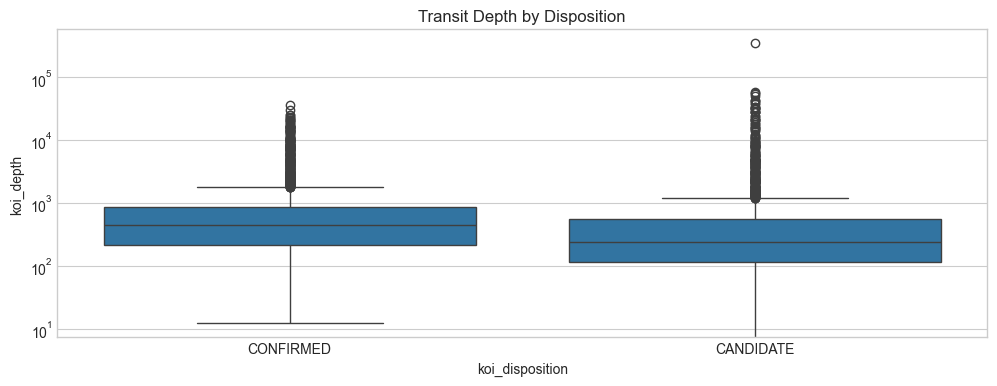


koi_fpflag_nt value counts:
 koi_fpflag_nt
0      4720
1         4
465       1
Name: count, dtype: int64

koi_fpflag_ss value counts:
 koi_fpflag_ss
0    4709
1      16
Name: count, dtype: int64

koi_fpflag_co value counts:
 koi_fpflag_co
0    4725
Name: count, dtype: int64

koi_fpflag_ec value counts:
 koi_fpflag_ec
0    4725
Name: count, dtype: int64


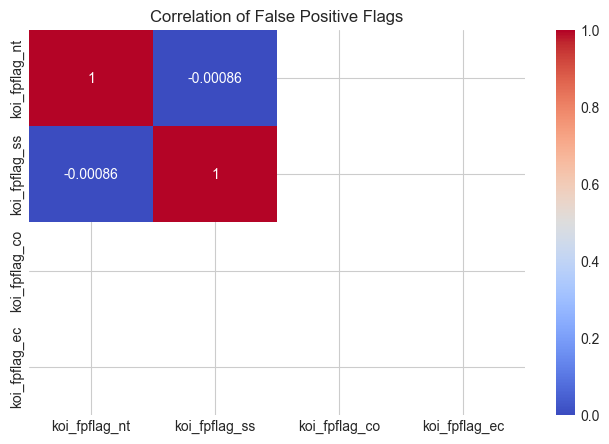

In [38]:
plot_EAD(df_binary)

## Prepare data before model training

### Missing value impute

In [ ]:
def remove_rows_over_50_missing(df):
    """
    Removes rows with more than 50% missing values.

    Parameters:
        df (pd.DataFrame): Input DataFrame.

    Returns:
        pd.DataFrame: DataFrame with rows >50% missing removed.
    """
    # Compute fraction of missing per row
    row_missing_frac = df.isnull().mean(axis=1)
    
    # Rows with more than 50% missing
    rows_over_50 = row_missing_frac[row_missing_frac > 0.5].index.tolist()
    
    print(f"Number of rows with >50% missing: {len(rows_over_50)}")
    print("Indices of rows with >50% missing:")
    print(rows_over_50)
    
    # Remove those rows
    df_cleaned = df.drop(index=rows_over_50)
    print(f"Shape before: {df.shape}, Shape after removal: {df_cleaned.shape}")
    
    return df_cleaned


In [ ]:
def clean_and_impute(df, target_col="label"):
    """
    - Keeps the target column untouched.
    - For numeric columns: imputes missing values with column mean.
    - For non-numeric columns: drops them.
    
    Parameters:
        df (pd.DataFrame): Input dataframe
        target_col (str): Name of target/label column to preserve
        
    Returns:
        pd.DataFrame: Cleaned dataframe
    """
    df_cleaned = df.copy()



    # Iterate over columns
    for col in df.columns:
        if col == target_col:
            continue  # skip label column

        if pd.api.types.is_numeric_dtype(df[col]):
            if df[col].isnull().any():
                df_cleaned[col] = df[col].fillna(df[col].mean())
        else:
            df_cleaned = df_cleaned.drop(columns=[col])
            print(f"Dropped non-numeric column: {col}")

    return df_cleaned

Number of rows with >50% missing: 106
Indices of rows with >50% missing:
[479, 746, 822, 970, 1101, 1242, 1502, 1602, 1673, 1889, 1890, 1923, 1934, 2018, 2210, 5527, 5929, 6109, 6116, 6192, 6316, 6348, 6467, 6514, 6516, 6529, 6566, 6570, 6581, 6615, 6623, 6650, 6675, 6680, 6686, 6768, 6799, 6800, 6811, 6862, 6901, 6984, 7012, 7013, 7045, 7056, 7066, 7068, 7071, 7075, 7076, 7086, 7091, 7095, 7106, 7127, 7132, 7150, 7160, 7177, 7190, 7191, 7204, 7222, 7280, 7327, 7335, 7346, 7366, 7367, 7368, 7395, 7450, 7452, 7460, 7461, 7463, 7484, 7488, 7499, 7603, 7614, 7684, 7732, 7926, 8183, 8441, 8442, 8454, 8464, 8473, 8561, 8571, 8751, 8784, 8803, 8974, 8981, 9004, 9060, 9116, 9152, 9244, 9348, 9393, 9517]
Shape before: (4725, 42), Shape after removal: (4619, 42)


,koi_disposition,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,koi_time0bk,koi_time0bk_err1,...,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,label
0,CONFIRMED,0,0,0,0,9.488036,0.000028,-0.000028,170.538750,0.002160,...,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,1
1,CONFIRMED,0,0,0,0,54.418383,0.000248,-0.000248,162.513840,0.003520,...,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,1
2,CANDIDATE,0,0,0,0,19.899140,0.000015,-0.000015,175.850252,0.000581,...,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436,0
4,CONFIRMED,0,0,0,0,2.525592,0.000004,-0.000004,171.595550,0.001130,...,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509,1
5,CONFIRMED,0,0,0,0,11.094321,0.000020,-0.000020,171.201160,0.001410,...,4.486,0.054,-0.229,0.972,0.315,-0.105,296.28613,48.224670,15.714,1


df size:  189379
✅ Scaler saved to results/Kepler subset/scaler.pkl


### Split into X, y and train, val & test

In [ ]:

def split_X_y(df):
    """
    Splits a DataFrame into features X and target y.
    
    Parameters:
        df (pd.DataFrame): The full dataset with features and target.
    
    Returns:
        X (pd.DataFrame): Feature columns.
        y (pd.Series): Target column.
    """
    # print("koi_disposition" in df.columns)
    if "koi_disposition" in df.columns:
        df = df.drop(columns="koi_disposition")
        # print("columns dropped")
        # print("koi_disposition" in df.columns)

    df = clean_and_impute(df)
    print("df size: ", df.size)
    y = df["label"]          # target column
    X = df.drop(columns="label")
    return X, y


def split_train_val_test_scale(X, y, train_ratio=0.7, random_seed=42):
    """
    Splits features X and target y into train/validation/test sets and scales numeric features with MinMaxScaler.
    Non-numeric columns are automatically removed.

    Parameters:
        X (pd.DataFrame or np.array): Features.
        y (pd.Series or np.array): Target.
        train_ratio (float): Proportion of data for training (default 0.7).
        random_seed (int): Random seed for reproducibility (default 42).

    Returns:
        X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, scaler
    """
    # Keep only numeric columns
    numeric_cols = X.select_dtypes(include=["number"]).columns
    non_numeric_cols = [col for col in X.columns if col not in numeric_cols]
    if non_numeric_cols:
        print(f"Warning: Non-numeric columns removed before scaling: {non_numeric_cols}")
    X_numeric = X[numeric_cols]

    # First split: train vs (val+test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_numeric, y, train_size=train_ratio, random_state=random_seed, stratify=y
    )

    # Second split: validation vs test (50/50 of the remaining data)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, train_size=0.5, random_state=random_seed, stratify=y_temp
    )

    # Scale features
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, scaler

def save_scaler(scaler, results_path="results", name="scaler.pkl"):
    os.makedirs(results_path, exist_ok=True)
    scaler_path = os.path.join(results_path, name)
    joblib.dump(scaler, scaler_path)
    print(f"✅ Scaler saved to {scaler_path}")

In [ ]:
df_binary_cleaned = remove_rows_over_50_missing(df_binary)
display(df_binary_cleaned.head())
X, y = split_X_y(df_binary_cleaned)
X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test, scaler = split_train_val_test_scale(X, y)

save_scaler(scaler, results_path=f"results/{data_name}/", name="scaler.pkl")

## Model

In [ ]:
def train_random_forest(X_train, y_train, **kwargs):
    """Train a Random Forest classifier."""
    rf = RandomForestClassifier(random_state=42, **kwargs)
    rf.fit(X_train, y_train)
    return rf

def train_gradient_boosting(X_train, y_train, **kwargs):
    """Train a Gradient Boosting classifier."""
    gb = GradientBoostingClassifier(random_state=42, **kwargs)
    gb.fit(X_train, y_train)
    return gb

def train_xgboost(X_train, y_train, **kwargs):
    """Train an XGBoost classifier."""
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, **kwargs)
    xgb.fit(X_train, y_train)
    return xgb

def train_adaboost(X_train, y_train, **kwargs):
    """
    Train an AdaBoost classifier.
    Returns:
        AdaBoostClassifier: Trained AdaBoost model
    """
    ada = AdaBoostClassifier(
        random_state=42, 
        **kwargs
    )
    
    ada.fit(X_train, y_train)
    return ada

In [ ]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluates a classification model and returns metrics in a dictionary.
    Also prints a summary.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None
    cm = confusion_matrix(y_test, y_pred)

    # Print summary
    print(f"==== {model_name} Evaluation ====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    if auc is not None:
        print(f"ROC-AUC  : {auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("==========================")

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": auc
    }


def compare_models(results):
    """
    Takes a list of results dictionaries and visualizes metrics.
    """
    df_results = pd.DataFrame(results)

    # Melt dataframe for plotting
    df_melted = df_results.melt(id_vars="model", var_name="metric", value_name="score")
    df_melted = df_melted[df_melted["metric"] != "roc_auc"]  # exclude AUC from barplot (better in ROC plot)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melted, x="metric", y="score", hue="model")
    plt.title("Model Comparison (Accuracy, Precision, Recall, F1)")
    plt.ylim(0, 1)
    plt.legend(title="Model")
    plt.show()


def plot_roc_curves(models, X_test, y_test, theme="dark"):
    """
    Plots ROC curves for multiple models in a modern, streamlit-style look.
    
    Parameters:
        models (dict): { "ModelName": trained_model }
        X_test (np.array): Test features
        y_test (np.array): Test labels
        theme (str): "dark" (default) or "light"
    """
    # Streamlit-like colors
    palette = [
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
        "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"
    ]
    
    if theme == "dark":
        plt.style.use("dark_background")
        bg_color = "#0E1117"
        grid_color = "#30343F"
    else:
        plt.style.use("seaborn-v0_8-whitegrid")
        bg_color = "#ffffff"
        grid_color = "#e5e5e5"

    plt.figure(figsize=(5, 6))
    ax = plt.gca()
    ax.set_facecolor(bg_color)

    for i, (model_name, model) in enumerate(models.items()):
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            plt.plot(
                fpr, tpr,
                label=f"{model_name} (AUC={auc:.3f})",
                linewidth=2.2,
                color=palette[i % len(palette)]
            )

    # Random baseline
    plt.plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.7, label="Random Guess")

    # Labels and title
    plt.xlabel("False Positive Rate", fontsize=12, labelpad=10)
    plt.ylabel("True Positive Rate", fontsize=12, labelpad=10)
    plt.title("ROC Curves", fontsize=14, pad=15, weight="bold")

    # Grid
    plt.grid(True, linestyle="--", alpha=0.3, color=grid_color)

    # Legend
    plt.legend(
        loc="lower right",
        fontsize=10,
        frameon=True,
        facecolor=bg_color,
        edgecolor=grid_color
    )

    plt.tight_layout()
    plt.show()



In [46]:
def plot_roc_curves_info(models, X_test, y_test, save_path=""):
    """
    Plots ROC curves for multiple models using default matplotlib style,
    and returns a dataframe with ROC info.
    
    Parameters:
        models (dict): {"ModelName": trained_model}
        X_test (np.array): Test features
        y_test (np.array): Test labels
        save_path (str): path to save df_ROC_info
        
    Returns:
        df_ROC_info (pd.DataFrame): False positive rate, true positive rate, thresholds for all models
    """
    
    plt.figure(figsize=(6, 6))  # Default figure size
    roc_data = []

    for model_name, model in models.items():
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, thresholds = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            
            # Plot ROC curve with default colors
            plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})", linewidth=2)
            
            # Save ROC info
            for fp, tp, thr in zip(fpr, tpr, thresholds):
                roc_data.append({
                    "Model": model_name,
                    "FPR": fp,
                    "TPR": tp,
                    "Threshold": thr
                })
    
    # Random baseline
    plt.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.7, label="Random Guess")
    
    # Labels, title, grid
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
    
    # Create dataframe and save to Excel
    df_ROC_info = pd.DataFrame(roc_data)
    df_ROC_info.to_excel(save_path, index=False)
    
    return df_ROC_info





### Train model

In [47]:
# Train models
rf_model = train_random_forest(X_train_scaled, y_train, n_estimators=300, max_depth=10)
gb_model = train_gradient_boosting(X_train_scaled, y_train, n_estimators=300, learning_rate=0.05)
xgb_model = train_xgboost(X_train_scaled, y_train, n_estimators=300, max_depth=5, learning_rate=0.05)
ada_model = train_adaboost(X_train_scaled, y_train, n_estimators=300, learning_rate=1.0)

c:\Projects\NASA Space App Challenge - XOXOplanet\xoxoplanet-nasa2025\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:34:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Results

==== RandomForest Evaluation ====
Accuracy : 0.8658
Precision: 0.8807
Recall   : 0.8956
F1 Score : 0.8881
ROC-AUC  : 0.9318
Confusion Matrix:
[[231  50]
 [ 43 369]]
==== GradientBoosting Evaluation ====
Accuracy : 0.8773
Precision: 0.8884
Recall   : 0.9078
F1 Score : 0.8980
ROC-AUC  : 0.9330
Confusion Matrix:
[[234  47]
 [ 38 374]]
==== XGBoost Evaluation ====
Accuracy : 0.8759
Precision: 0.8937
Recall   : 0.8981
F1 Score : 0.8959
ROC-AUC  : 0.9337
Confusion Matrix:
[[237  44]
 [ 42 370]]
==== AdaBoost Evaluation ====
Accuracy : 0.8615
Precision: 0.8762
Recall   : 0.8932
F1 Score : 0.8846
ROC-AUC  : 0.9266
Confusion Matrix:
[[229  52]
 [ 44 368]]


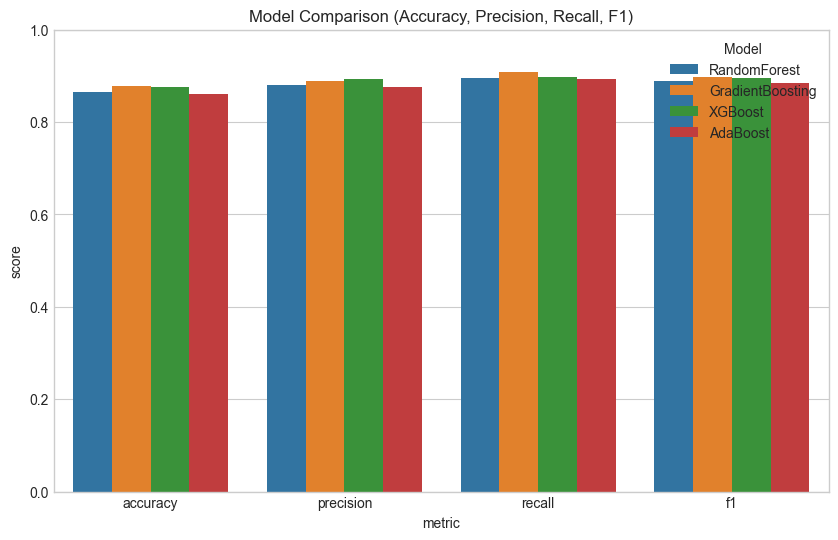

In [52]:
# Evaluate and collect results
RF_model_name = "RandomForest"
GB_model_name = "GradientBoosting"
XGB_model_name = "XGBoost"
ADAB_model_name = "AdaBoost"

results = []
X_val_or_test = X_val_scaled
y_val_or_test = y_val
results.append(evaluate_model(rf_model, X_val_or_test, y_val_or_test, RF_model_name))
results.append(evaluate_model(gb_model, X_val_or_test, y_val_or_test, GB_model_name))
results.append(evaluate_model(xgb_model, X_val_or_test, y_val_or_test, XGB_model_name))
results.append(evaluate_model(ada_model, X_val_or_test, y_val_or_test, ADAB_model_name))

# Compare models visually
compare_models(results)

models_dict = {
    RF_model_name: rf_model,
    GB_model_name: gb_model,
    XGB_model_name: xgb_model,
    ADAB_model_name: ada_model
}


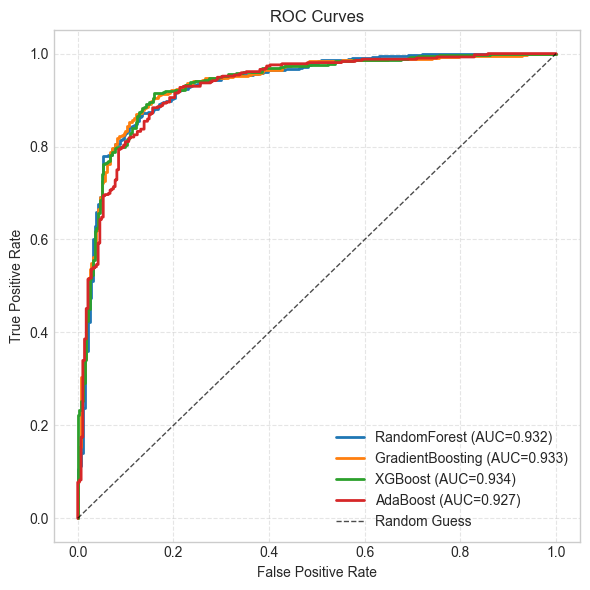

In [ ]:
df_ROC_info = plot_roc_curves_info(models_dict, X_val_or_test, y_val_or_test, save_path=f"results/{data_name}/ROC_info.xlsx")

## Save

In [56]:
def save_dict_as_json(data_dict, filename, results_path):
    """
    Save a dictionary as a JSON file.

    Parameters:
        data_dict (dict): Dictionary to save
        filename (str): Name of JSON file (e.g., "results.json")
        results_path (str): Path where to save. Defaults to "results/"
    """
    
    os.makedirs(results_path, exist_ok=True)
    file_path = os.path.join(results_path, filename)
    with open(file_path, "w") as f:
        json.dump(data_dict, f, indent=4)
    print(f"JSON saved to {file_path}")


def save_models(models_dict, results_path):
    """
    Save trained sklearn models to disk using joblib.

    Parameters:
        models_dict (dict): Dictionary {model_name: trained_model}
        results_path (str): Path where to save. Defaults to "results/"
    """
    os.makedirs(results_path, exist_ok=True)
    for name, model in models_dict.items():
        file_path = os.path.join(results_path, f"{name}.joblib")
        joblib.dump(model, file_path)
        print(f"Model '{name}' saved to {file_path}")


def save_array(arr, path, filename):
    """
    Save numpy array to disk as .npy
    """
    os.makedirs(path, exist_ok=True)
    file_path = os.path.join(path, f"{filename}.npy")
    np.save(file_path, arr)
    print(f"Saved array to {file_path}")
    return file_path


save_array(X_test_scaled, path=f"results/{data_name}/", filename="X_test_scaled")

Saved array to results/Kepler subset/X_test_scaled.npy


'results/Kepler subset/X_test_scaled.npy'

In [57]:
# Save dictionaries as JSON
save_dict_as_json(results, "results.json", results_path=f"results/{data_name}/")

# Save trained models themselves
save_models(models_dict, results_path=f"results/{data_name}/models/")

# Save feature order at training
features = list(X.columns)
with open(f"results/{data_name}/features.json", "w") as f:
    json.dump(features, f)


JSON saved to results/Kepler subset/results.json
Model 'RandomForest' saved to results/Kepler subset/models/RandomForest.joblib
Model 'GradientBoosting' saved to results/Kepler subset/models/GradientBoosting.joblib
Model 'XGBoost' saved to results/Kepler subset/models/XGBoost.joblib
Model 'AdaBoost' saved to results/Kepler subset/models/AdaBoost.joblib
